In [1]:
import sys
sys.path.insert(0, "../..")
import pandas as pd
from process_ela_icc import load_icc, components_to_dataframe
import icc_analysis as ia
from ela_cv_features import CV_SAFE, CV_CAVEATED, CV_EXCLUDED
# or an absolute path
from pathlib import Path


In [2]:
BASE = Path("/Users/leekaijen/t7ssd/featELA/")


In [3]:
ICC_SOURCES = {d: BASE / f"dim{d}featELA" / "ela_icc_results.pkl" for d in (2, 5, 10)}
df  = pd.concat([components_to_dataframe(load_icc(p)) for p in ICC_SOURCES.values()],
                ignore_index=True)
tab = ia.prepare(df)                     # drops omitted features, flags no_signal

ranked = ia.rank_within_function(tab)
per_func, wins = ia.win_counts(ranked)

74,880 cells | 45 features x 24 functions x 6 strategies | dims [2, 5, 10]
no-signal cells (sigma2_between <= 0): 13.4%
  of which raw ICC < 0: 13.4% (kept, not clipped)


In [4]:
# --- ICC side ---
from process_ela_icc import load_icc, components_to_dataframe
import icc_analysis as ia

ICC_SRC = {d: BASE / f"dim{d}featELA" / "ela_icc_results.pkl" for d in (2, 5, 10)}
df  = pd.concat([components_to_dataframe(load_icc(p)) for p in ICC_SRC.values()],
                ignore_index=True)
tab = ia.prepare(df)
sc  = ia.scope_comparable(tab, mode="all")
r   = ia.component_ratios(sc)

74,880 cells | 45 features x 24 functions x 6 strategies | dims [2, 5, 10]
no-signal cells (sigma2_between <= 0): 13.4%
  of which raw ICC < 0: 13.4% (kept, not clipped)
scope[all]: kept 8,301 of 12,408 (function, feature, size) cells (66.9%) with detectable signal
  most cells dropped: f20 (2917), f23 (2870), f24 (2842), f5 (2494), f16 (1963)


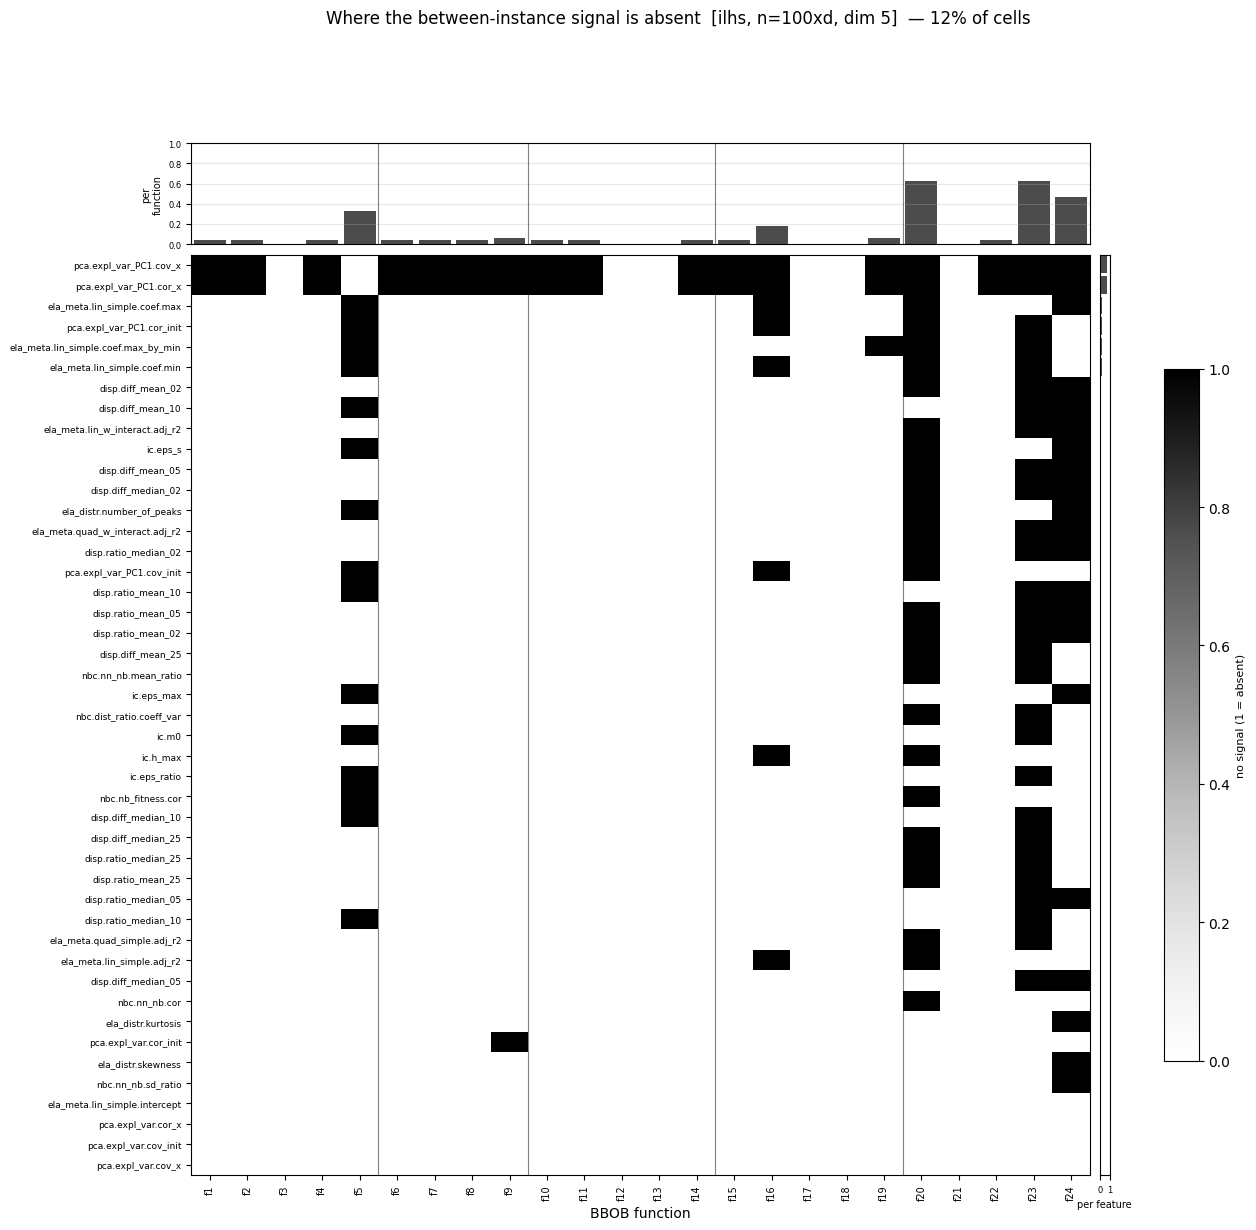

In [17]:
# 2 — where is measurement possible?
_ = ia.heatmap_no_signal(tab, dimension=5, strategy="ilhs", size=100)

In [6]:
# 3 — the same, as quotable numbers
# ia.no_signal_summary(tab, 5, "sobol", 100, by="func")       # which landscapes
# ia.no_signal_summary(tab, 5, "sobol", 100, by="feature")    # which features
# ia.no_signal_summary(tab, 5, size=100, by="strategy")       # does a sampler create them?
t = ia.no_signal_summary(tab, by="overall")
t.sort_values(["dimension", "size", "strategy"]).reset_index(drop=True)

,dimension,strategy,size,n_cells,n_no_signal,med_icc_where_signal,pct_no_signal
0,2,cma_random,25,960,180,0.017,18.8
1,2,ilhs,25,960,125,0.278,13.0
2,2,lhs,25,960,124,0.194,12.9
3,2,lhs_random_cd,25,960,100,0.297,10.4
4,2,sobol,25,960,112,0.247,11.7
...,...,...,...,...,...,...,...
67,10,ilhs,100,1080,169,0.261,15.6
68,10,lhs,100,1080,139,0.296,12.9
69,10,lhs_random_cd,100,1080,144,0.390,13.3
70,10,sobol,100,1080,148,0.418,13.7


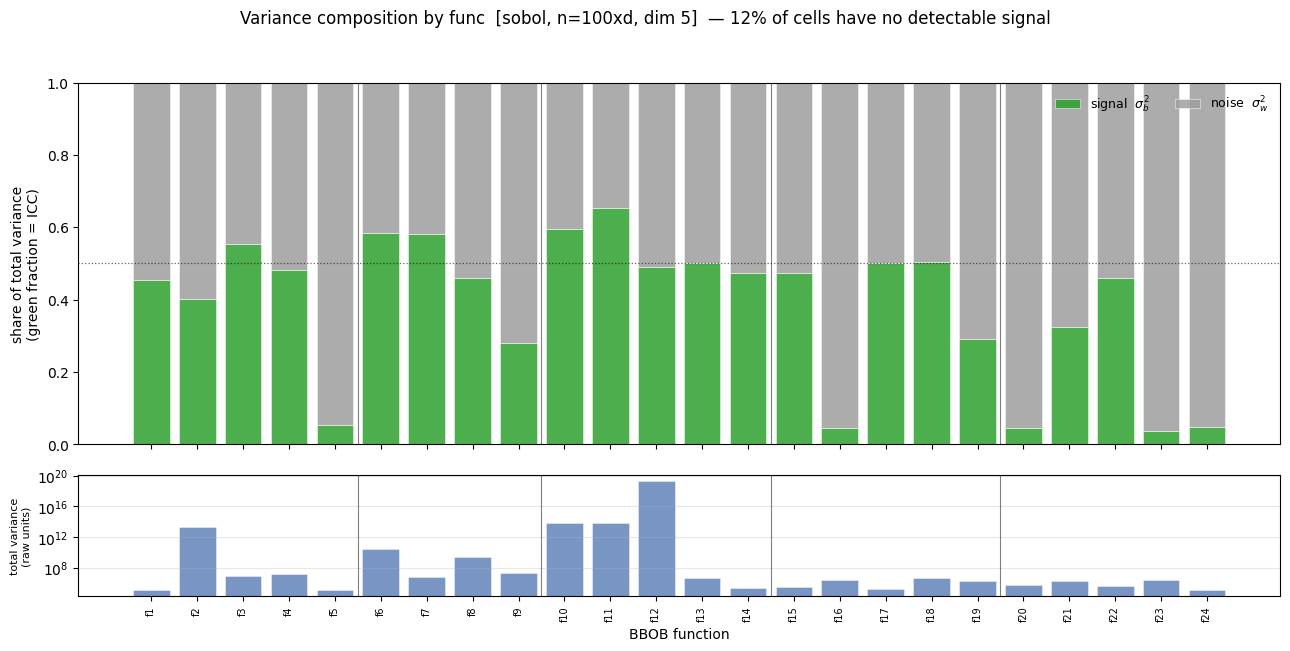

In [7]:
# 1 — what ICC means: the variance split
_ = ia.plot_variance_composition(tab, 5, "sobol", 100)

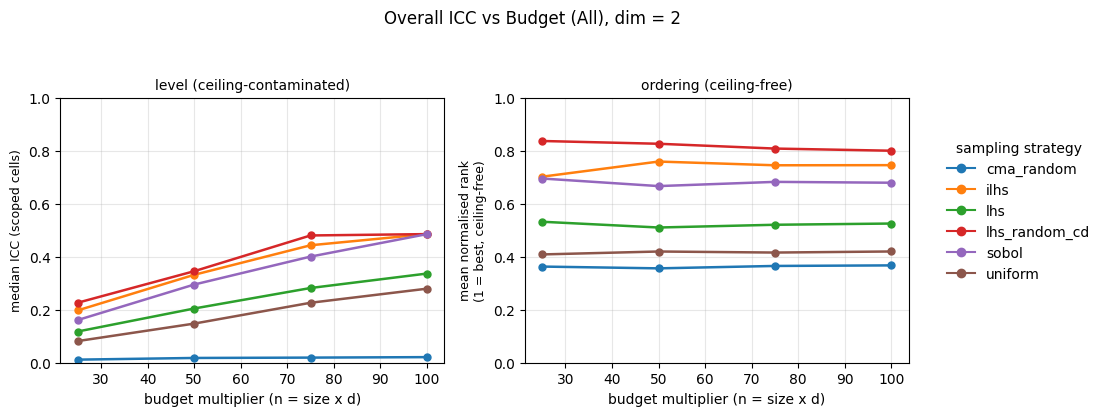

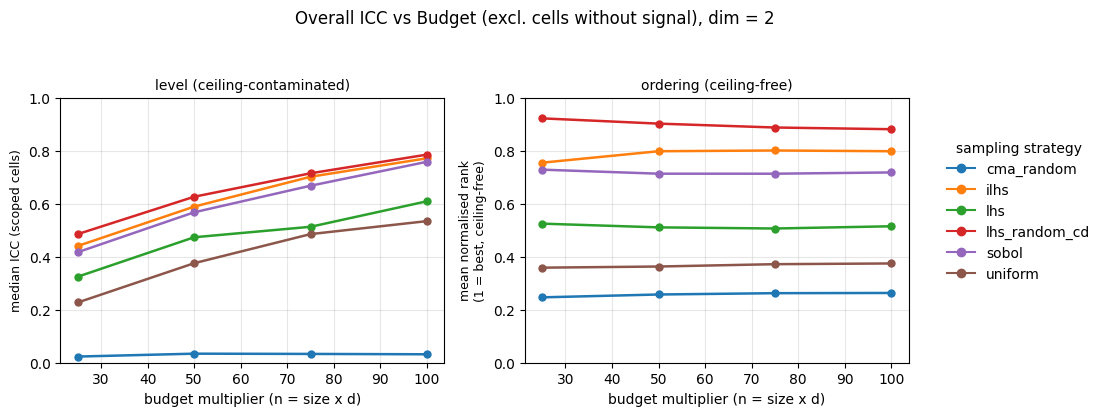

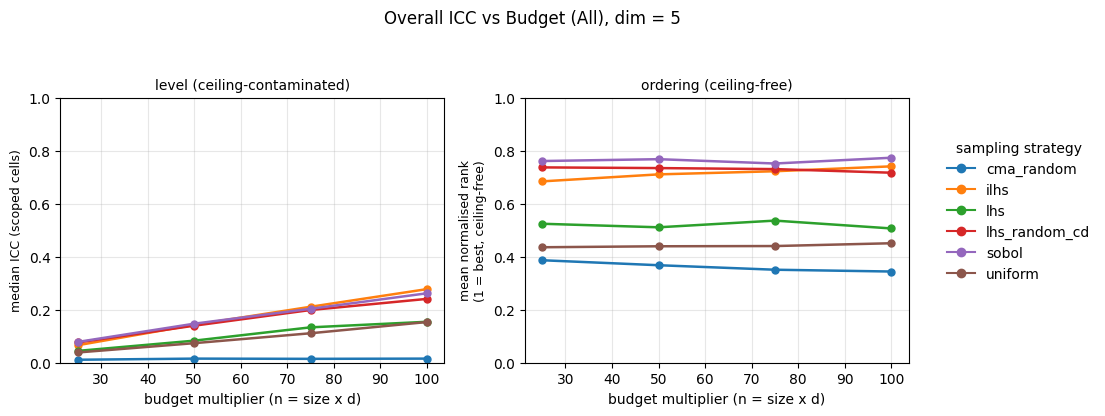

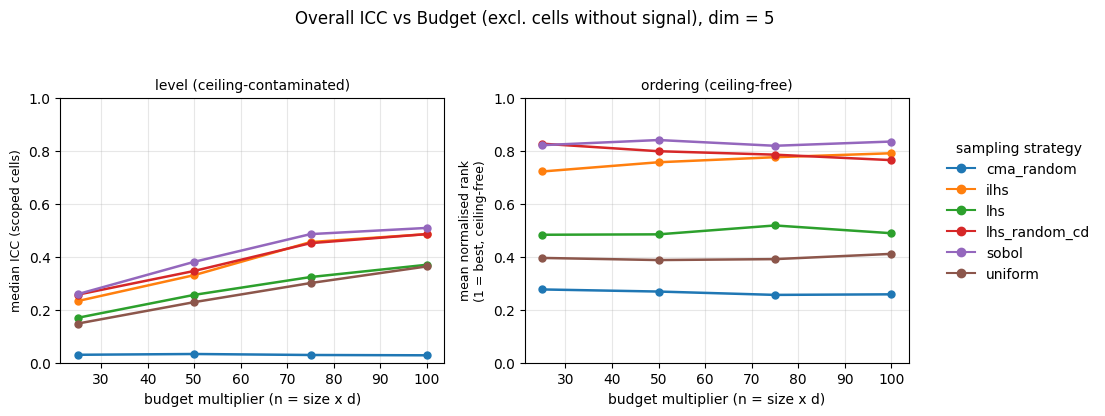

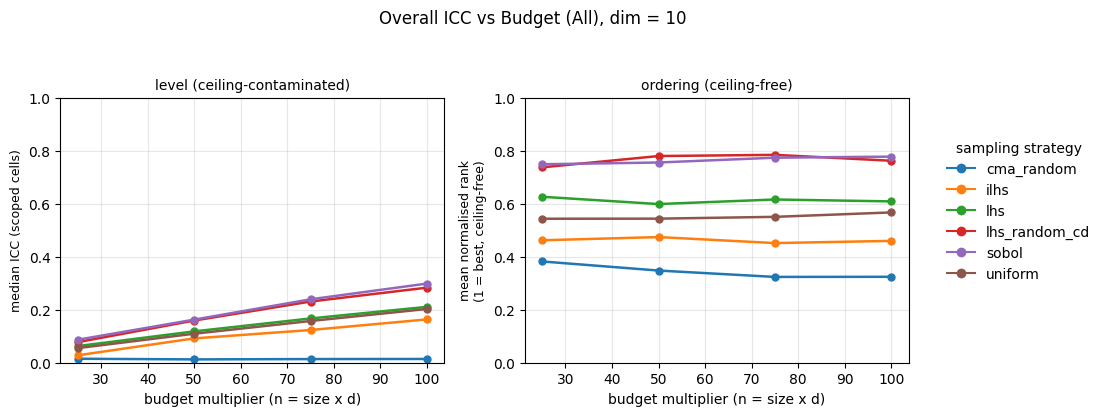

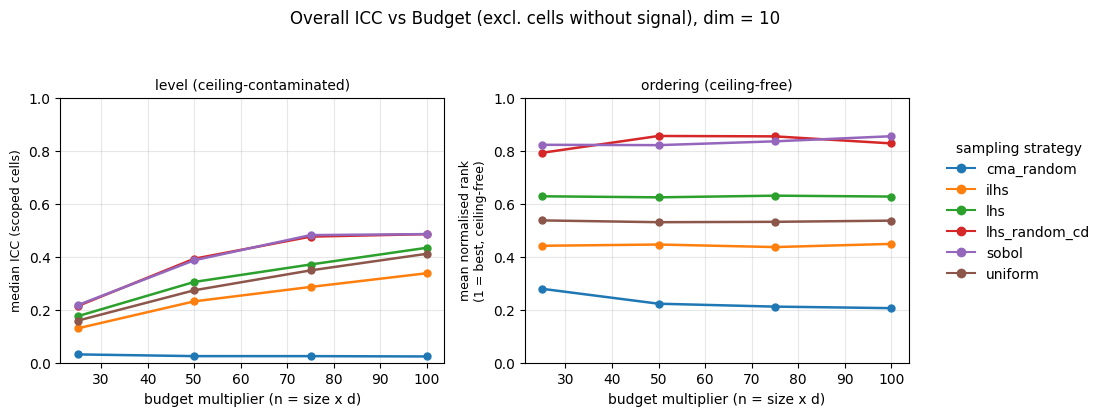

In [12]:
# 4 + 5 — unscoped vs scoped, side by side (this pair justifies the scoping)
_ = ia.plot_icc_overall_vs_budget(tab, show_band=False, dimension=2, title="Overall ICC vs Budget (All), dim = 2 ")   # all cells
_ = ia.plot_icc_overall_vs_budget(sc, show_band=False, dimension=2, title="Overall ICC vs Budget (excl. cells without signal), dim = 2")   # signal-bearing only
_ = ia.plot_icc_overall_vs_budget(tab, show_band=False, dimension=5, title="Overall ICC vs Budget (All), dim = 5 ")   # all cells
_ = ia.plot_icc_overall_vs_budget(sc, show_band=False, dimension=5, title="Overall ICC vs Budget (excl. cells without signal), dim = 5")   # signal-bearing only
_ = ia.plot_icc_overall_vs_budget(tab, show_band=False, dimension=10, title="Overall ICC vs Budget (All), dim = 10 ")   # all cells
_ = ia.plot_icc_overall_vs_budget(sc, show_band=False, dimension=10, title="Overall ICC vs Budget (excl. cells without signal), dim = 10")   # signal-bearing only

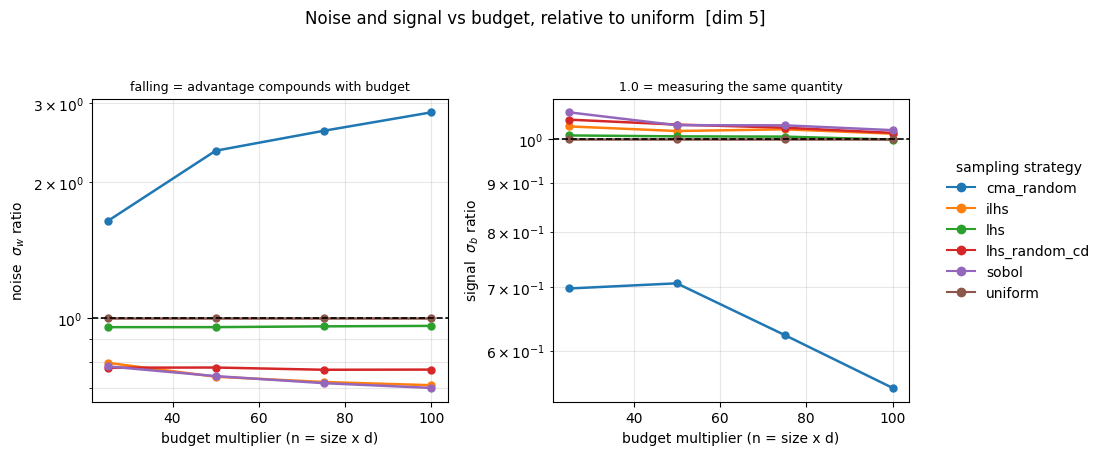

In [9]:
# 7 — why cma_random fails: the σ_b / σ_w split
_ = ia.plot_component_ratios_vs_budget(r, dimension=5)

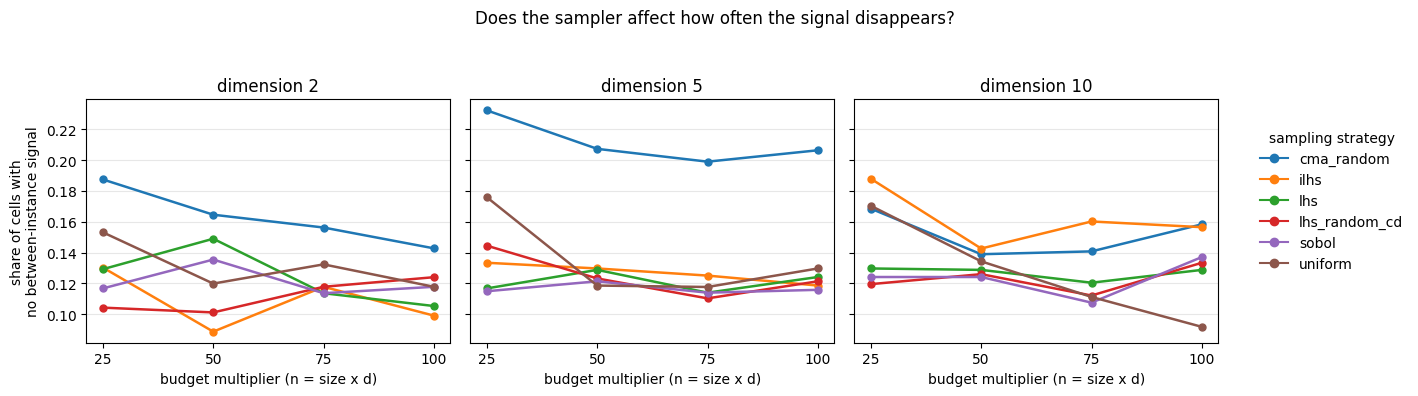

In [10]:
_ = ia.plot_no_signal_by_config(tab)                      # lines, one panel per dimension
